# Model Tuning

This notebook compares random forest and XGBoost with the logistic-regression benchmark.

All models are trained on FY2010–FY2017 and evaluated on FY2018. FY2019 remains untouched for final evaluation.

Hyperparameter tuning uses expanding chronological folds within the training period. The final operating threshold is selected on FY2018 by maximizing F1.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42
FEATURES_PATH = "../data/processed/sba_7a_features.csv"
TARGET_COL = "default"

TRAIN_END_YEAR = 2017
VALIDATION_YEAR = 2018
TEST_YEAR = 2019

In [13]:
df = pd.read_csv(
    FEATURES_PATH,
    dtype={
        "naics_sector": "string",
        "CongressionalDistrict": "string",
        "approval_month": "string",
    },
    low_memory=False,
)

train_df = df.loc[df["ApprovalFY"] <= TRAIN_END_YEAR].copy()
validation_df = df.loc[df["ApprovalFY"] == VALIDATION_YEAR].copy()
test_df = df.loc[df["ApprovalFY"] == TEST_YEAR].copy()

assert len(train_df) + len(validation_df) + len(test_df) == len(df)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_validation = validation_df.drop(columns=[TARGET_COL])
y_validation = validation_df[TARGET_COL]

print(f"Training loans: {len(X_train):,} | default rate: {y_train.mean():.2%}")
print(
    f"Validation loans: {len(X_validation):,} | "
    f"default rate: {y_validation.mean():.2%}"
)
print(f"Held-out FY2019 test loans: {len(test_df):,}")

Training loans: 355,031 | default rate: 7.55%
Validation loans: 42,237 | default rate: 10.13%
Held-out FY2019 test loans: 31,606


## Preprocessing

The preprocessing pipeline is identical to the baseline-model notebook. It is fit only on training data within each model pipeline and tuning fold.

In [14]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True,
    )),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

In [15]:
def evaluate_model(model_name, fitted_pipeline, X, y_true, threshold=0.50):
    """Evaluate a fitted binary classifier on one dataset."""
    probabilities = fitted_pipeline.predict_proba(X)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    return {
        "model": model_name,
        "threshold": threshold,
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "brier_score": brier_score_loss(y_true, probabilities),
    }

## Initial model comparison

The logistic-regression benchmark is refit here so that this notebook is reproducible on its own.

Random forest tests nonlinear interactions. XGBoost is expected to be the strongest tree-based candidate for this structured tabular dataset.

Class imbalance is handled through class weights for random forest and `scale_pos_weight` for the initial XGBoost model.

In [16]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
class_ratio = negative_count / positive_count

print(f"Training negative-to-positive ratio: {class_ratio:.2f}:1")

Training negative-to-positive ratio: 12.24:1


In [17]:
models = {
    "Logistic regression": LogisticRegression(
        max_iter=5_000,
        tol=1e-4,
        solver="saga",
        random_state=RANDOM_STATE,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=class_ratio,
        reg_lambda=1.0,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

In [18]:
fitted_models = {}
initial_results = []

for model_name, classifier in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", clone(classifier)),
    ])

    pipeline.fit(X_train, y_train)

    fitted_models[model_name] = pipeline
    initial_results.append(
        evaluate_model(
            model_name=model_name,
            fitted_pipeline=pipeline,
            X=X_validation,
            y_true=y_validation,
        )
    )

initial_results_df = (
    pd.DataFrame(initial_results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

initial_results_df.round(4)

,model,threshold,pr_auc,roc_auc,precision,recall,f1,brier_score
0,XGBoost,0.5,0.8227,0.9671,0.5775,0.9121,0.7072,0.0615
1,Random forest,0.5,0.7819,0.9406,0.7661,0.7185,0.7416,0.0483
2,Logistic regression,0.5,0.5864,0.8777,0.7244,0.4246,0.5354,0.0616


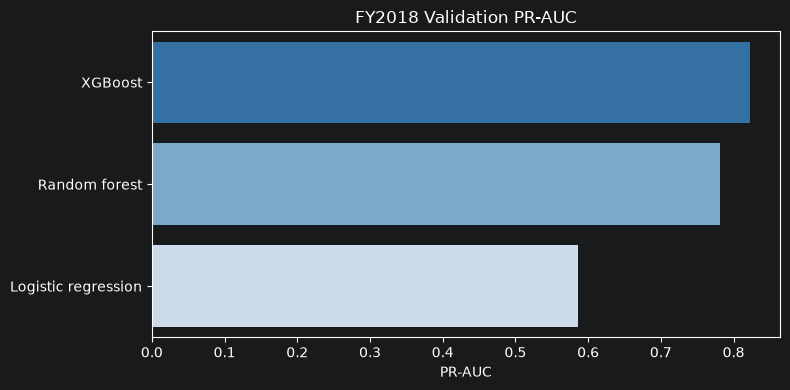

In [46]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=initial_results_df,
    x="pr_auc",
    y="model",
    hue="model",
    palette="Blues_r",
)

plt.title("FY2018 Validation PR-AUC")
plt.xlabel("PR-AUC")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Initial comparison conclusion

XGBoost achieved the highest FY2018 validation PR-AUC and is therefore selected for hyperparameter tuning.

Random forest achieved stronger F1 and calibration at the default 0.50 threshold. However, 0.50 is not the final operating threshold; the final threshold will be selected separately by maximizing F1 on FY2018.

Because XGBoost has substantially stronger ranking performance, tuning will focus on XGBoost. The untouched FY2019 test set will not be used during this process.

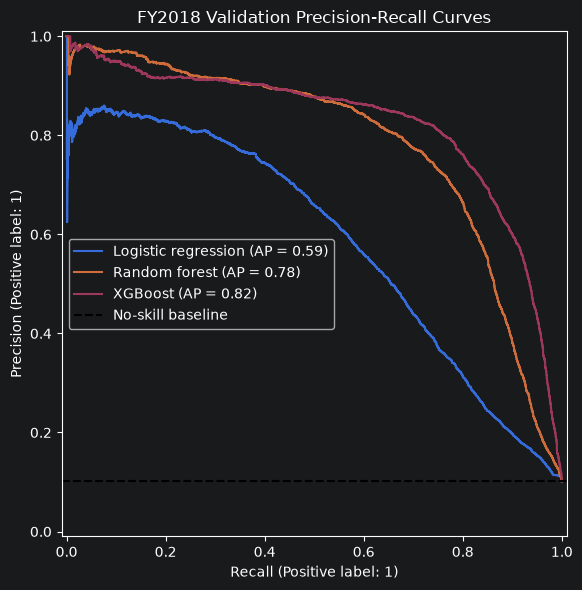

In [20]:
plt.figure(figsize=(8, 6))

for model_name, pipeline in fitted_models.items():
    probabilities = pipeline.predict_proba(X_validation)[:, 1]

    PrecisionRecallDisplay.from_predictions(
        y_validation,
        probabilities,
        name=model_name,
        ax=plt.gca(),
    )

plt.axhline(
    y=y_validation.mean(),
    color="black",
    linestyle="--",
    label="No-skill baseline",
)

plt.title("FY2018 Validation Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

## XGBoost tuning with expanding temporal validation

Hyperparameters are tuned using only the FY2010–FY2017 training period.

Each validation fold uses a later year than its corresponding training data:

- Train FY2010–FY2014 → validate FY2015
- Train FY2010–FY2015 → validate FY2016
- Train FY2010–FY2016 → validate FY2017

The tuning objective is average precision, scikit-learn's implementation of PR-AUC.

In [21]:
def make_expanding_year_splits(years, validation_years):
    """Create chronological cross-validation index splits."""
    years = np.asarray(years)
    splits = []

    for validation_year in validation_years:
        train_indices = np.flatnonzero(years < validation_year)
        validation_indices = np.flatnonzero(years == validation_year)

        assert len(train_indices) > 0
        assert len(validation_indices) > 0

        splits.append((train_indices, validation_indices))

    return splits


temporal_cv = make_expanding_year_splits(
    years=X_train["ApprovalFY"],
    validation_years=[2015, 2016, 2017],
)

for fold_number, (train_indices, validation_indices) in enumerate(
    temporal_cv,
    start=1,
):
    print(
        f"Fold {fold_number}: "
        f"{len(train_indices):,} training rows, "
        f"{len(validation_indices):,} validation rows"
    )

Fold 1: 204,288 training rows, 52,176 validation rows
Fold 2: 256,464 training rows, 51,449 validation rows
Fold 3: 307,913 training rows, 47,118 validation rows


In [22]:
xgb_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

param_distributions = {
    "classifier__n_estimators": [300, 500],
    "classifier__learning_rate": [0.03, 0.05, 0.10],
    "classifier__max_depth": [3, 5, 7],
    "classifier__min_child_weight": [1, 5, 10],
    "classifier__subsample": [0.70, 0.85, 1.00],
    "classifier__colsample_bytree": [0.70, 0.85, 1.00],
    "classifier__reg_lambda": [1.0, 5.0, 10.0],
    "classifier__scale_pos_weight": [1.0, 5.0, 10.0, 15.0],
}

In [23]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="average_precision",
    cv=temporal_cv,
    refit=True,
    n_jobs=1,
    verbose=2,
    random_state=RANDOM_STATE,
    return_train_score=True,
)

xgb_search.fit(X_train, y_train)

print(f"Best temporal-CV PR-AUC: {xgb_search.best_score_:.4f}")
print("Best parameters:")
xgb_search.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__min_child_weight=10, classifier__n_estimators=500, classifier__reg_lambda=10.0, classifier__scale_pos_weight=10.0, classifier__subsample=1.0; total time=   2.1s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__min_child_weight=10, classifier__n_estimators=500, classifier__reg_lambda=10.0, classifier__scale_pos_weight=10.0, classifier__subsample=1.0; total time=   2.6s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__min_child_weight=10, classifier__n_estimators=500, classifier__reg_lambda=10.0, classifier__scale_pos_weight=10.0, classifier__subsample=1.0; total time=   3.4s
[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=3, classifier__min_child

{'classifier__subsample': 0.85,
 'classifier__scale_pos_weight': 5.0,
 'classifier__reg_lambda': 10.0,
 'classifier__n_estimators': 300,
 'classifier__min_child_weight': 5,
 'classifier__max_depth': 7,
 'classifier__learning_rate': 0.1,
 'classifier__colsample_bytree': 0.85}

In [24]:
tuned_xgb = xgb_search.best_estimator_

tuned_xgb_result = evaluate_model(
    model_name="Tuned XGBoost",
    fitted_pipeline=tuned_xgb,
    X=X_validation,
    y_true=y_validation,
)

comparison_results_df = pd.concat(
    [
        initial_results_df,
        pd.DataFrame([tuned_xgb_result]),
    ],
    ignore_index=True,
).sort_values("pr_auc", ascending=False).reset_index(drop=True)

comparison_results_df.round(4)

,model,threshold,pr_auc,roc_auc,precision,recall,f1,brier_score
0,Tuned XGBoost,0.5,0.8257,0.9671,0.6710,0.8623,0.7547,0.0445
1,XGBoost,0.5,0.8227,0.9671,0.5775,0.9121,0.7072,0.0615
2,Random forest,0.5,0.7819,0.9406,0.7661,0.7185,0.7416,0.0483
3,Logistic regression,0.5,0.5864,0.8777,0.7244,0.4246,0.5354,0.0616


## Tuning Results

Randomized search evaluated 10 XGBoost configurations using expanding temporal validation within FY2010–FY2017.

The best configuration achieved mean temporal-CV PR-AUC of 0.8016:

- 300 trees
- Learning rate: 0.10
- Maximum depth: 7
- Minimum child weight: 5
- Subsample: 0.85
- Column subsample: 0.85
- L2 regularization: 10.0
- Positive-class weight: 5.0

When refit on the full FY2010–FY2017 training set, tuned XGBoost achieved the strongest FY2018 validation performance. It improved PR-AUC, F1 at the default threshold, and probability calibration relative to the initial XGBoost model.

Tuned XGBoost is selected as the final candidate. FY2019 remains untouched.

In [25]:
search_results_df = pd.DataFrame(xgb_search.cv_results_)

tuning_summary = (
    search_results_df[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_classifier__n_estimators",
            "param_classifier__learning_rate",
            "param_classifier__max_depth",
            "param_classifier__min_child_weight",
            "param_classifier__subsample",
            "param_classifier__colsample_bytree",
            "param_classifier__reg_lambda",
            "param_classifier__scale_pos_weight",
        ]
    ]
    .rename(
        columns={
            "rank_test_score": "rank",
            "mean_test_score": "mean_cv_pr_auc",
            "std_test_score": "std_cv_pr_auc",
            "mean_train_score": "mean_train_pr_auc",
            "param_classifier__n_estimators": "n_estimators",
            "param_classifier__learning_rate": "learning_rate",
            "param_classifier__max_depth": "max_depth",
            "param_classifier__min_child_weight": "min_child_weight",
            "param_classifier__subsample": "subsample",
            "param_classifier__colsample_bytree": "colsample_bytree",
            "param_classifier__reg_lambda": "reg_lambda",
            "param_classifier__scale_pos_weight": "scale_pos_weight",
        }
    )
    .sort_values("rank")
    .reset_index(drop=True)
)

tuning_summary.round(4)

,rank,mean_cv_pr_auc,std_cv_pr_auc,mean_train_pr_auc,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,scale_pos_weight
0,1,0.8016,0.0273,0.8275,300,0.10,7,5,0.85,0.85,10.0,5.0
1,2,0.8009,0.0263,0.8699,500,0.10,7,5,0.85,1.00,1.0,15.0
2,3,0.7937,0.0320,0.8133,500,0.05,7,1,1.00,0.85,10.0,10.0
3,4,0.7839,0.0305,0.7691,300,0.03,7,1,0.85,0.70,10.0,15.0
4,5,0.7813,0.0296,0.7644,300,0.03,7,5,0.85,1.00,10.0,15.0
5,6,0.7751,0.0272,0.7356,500,0.10,3,10,1.00,1.00,10.0,1.0
6,7,0.7628,0.0287,0.7211,500,0.10,3,1,0.70,1.00,1.0,10.0
7,8,0.7532,0.0299,0.6985,300,0.10,3,10,0.70,1.00,1.0,10.0
8,9,0.7516,0.0291,0.6999,300,0.10,3,1,0.85,1.00,1.0,10.0
9,10,0.7475,0.0291,0.6833,500,0.05,3,10,1.00,0.70,10.0,10.0


In [32]:
selected_model_name = comparison_results_df.loc[0, "model"]
all_fitted_models = {
    **fitted_models,
    "Tuned XGBoost": tuned_xgb,
}

selected_model = all_fitted_models[selected_model_name]
validation_probabilities = selected_model.predict_proba(X_validation)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_validation,
    validation_probabilities,
)

f1_scores = np.divide(
    2 * precision[:-1] * recall[:-1],
    precision[:-1] + recall[:-1],
    out=np.zeros_like(precision[:-1]),
    where=(precision[:-1] + recall[:-1]) != 0,
)

best_threshold_index = np.argmax(f1_scores)
selected_threshold = thresholds[best_threshold_index]
selected_f1 = f1_scores[best_threshold_index]

print(f"Selected model: {selected_model_name}")
print(f"Selected threshold: {selected_threshold:.4f}")
print(f"Validation F1: {selected_f1:.4f}")

Selected model: Tuned XGBoost
Selected threshold: 0.7482
Validation F1: 0.7823


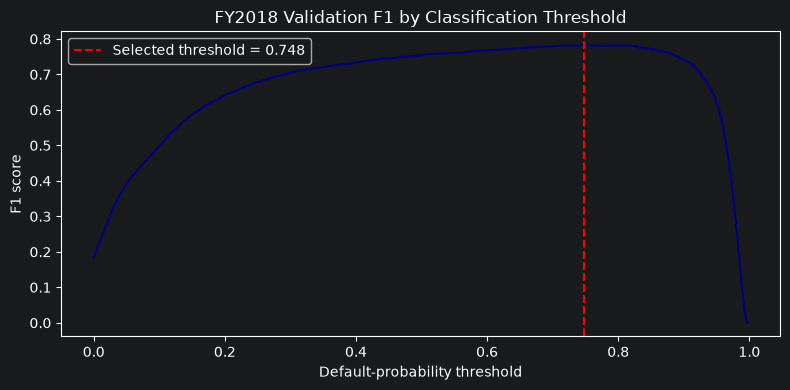

In [33]:
plt.figure(figsize=(8, 4))

plt.plot(thresholds, f1_scores, color="navy")
plt.axvline(
    selected_threshold,
    color="red",
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.3f}",
)

plt.title("FY2018 Validation F1 by Classification Threshold")
plt.xlabel("Default-probability threshold")
plt.ylabel("F1 score")
plt.legend()
plt.tight_layout()
plt.show()

Precision: 0.7798
Recall: 0.7849
F1: 0.7823


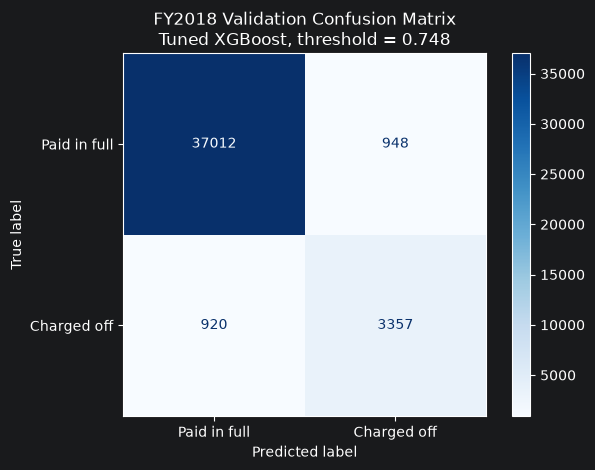

In [34]:
selected_predictions = (
    validation_probabilities >= selected_threshold
).astype(int)

print(
    f"Precision: "
    f"{precision_score(y_validation, selected_predictions):.4f}"
)
print(
    f"Recall: "
    f"{recall_score(y_validation, selected_predictions):.4f}"
)
print(
    f"F1: "
    f"{f1_score(y_validation, selected_predictions):.4f}"
)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["Paid in full", "Charged off"],
    cmap="Blues",
)

plt.title(
    "FY2018 Validation Confusion Matrix\n"
    f"Tuned XGBoost, threshold = {selected_threshold:.3f}"
)
plt.tight_layout()
plt.show()

## Selected Threshold Performance

Tuned XGBoost is selected by FY2018 PR-AUC. The operating threshold is selected separately by maximizing FY2018 F1.

The selected threshold is higher than 0.50 because it produces a more balanced precision–recall tradeoff. This threshold is now fixed and will be applied without modification to FY2019.

In [35]:
default_threshold_result = evaluate_model(
    model_name="Tuned XGBoost at 0.50",
    fitted_pipeline=selected_model,
    X=X_validation,
    y_true=y_validation,
    threshold=0.50,
)

selected_threshold_result = evaluate_model(
    model_name="Tuned XGBoost at selected threshold",
    fitted_pipeline=selected_model,
    X=X_validation,
    y_true=y_validation,
    threshold=selected_threshold,
)

threshold_comparison_df = pd.DataFrame(
    [default_threshold_result, selected_threshold_result]
)

threshold_comparison_df.round(4)

,model,threshold,pr_auc,roc_auc,precision,recall,f1,brier_score
0,Tuned XGBoost at 0.50,0.5000,0.8257,0.9671,0.6710,0.8623,0.7547,0.0445
1,Tuned XGBoost at selected threshold,0.7482,0.8257,0.9671,0.7798,0.7849,0.7823,0.0445


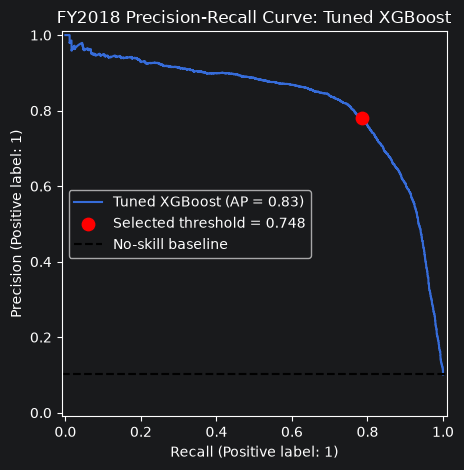

In [38]:
PrecisionRecallDisplay.from_predictions(
    y_validation,
    validation_probabilities,
    name="Tuned XGBoost",
)

plt.scatter(
    recall[best_threshold_index],
    precision[best_threshold_index],
    color="red",
    s=80,
    zorder=3,
    label=f"Selected threshold = {selected_threshold:.3f}",
)

plt.axhline(
    y=y_validation.mean(),
    color="black",
    linestyle="--",
    label="No-skill baseline",
)

plt.title("FY2018 Precision-Recall Curve: Tuned XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
from pathlib import Path
import joblib

MODEL_PATH = Path("../models/tuned_xgboost_pipeline.joblib")

model_artifact = {
    "model_name": selected_model_name,
    "pipeline": selected_model,
    "threshold": float(selected_threshold),
    "validation_pr_auc": float(
        average_precision_score(y_validation, validation_probabilities)
    ),
    "validation_f1": float(selected_f1),
    "feature_columns": X_train.columns.tolist(),
    "training_period": "FY2010-FY2017",
    "validation_period": "FY2018",
}

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_artifact, MODEL_PATH)

print(f"Saved model artifact to: {MODEL_PATH}")

Saved model artifact to: ..\models\tuned_xgboost_pipeline.joblib


## Tuning Conclusions

Tuned XGBoost was selected as the final candidate based on FY2018 validation PR-AUC.

Randomized search used 10 configurations and expanding temporal cross-validation within FY2010–FY2017. The selected configuration achieved mean temporal-CV PR-AUC of 0.8016 and FY2018 PR-AUC of 0.8257.

The FY2018 F1-maximizing threshold is 0.7482. At this threshold, tuned XGBoost achieved:

- Precision: 0.7798
- Recall: 0.7849
- F1: 0.7823

The model pipeline and locked threshold have been saved as a local artifact. FY2019 has not been used for model selection, tuning, threshold selection, or metric calculation.

The next notebook will evaluate this frozen model once on FY2019, assess calibration, interpret feature effects, and document the final limitations.

Because the randomized search sampled 10 configurations and the strongest temporal-CV candidates were close, this is a pragmatic tuned configuration rather than a claim of a globally optimal XGBoost model.